In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
#Se crea un array con una media de 20 y un std de 3.5
my_arr = np.random.normal(loc=20, scale=3.5, size=100)
my_arr

array([23.2952665 , 17.85566332, 29.45012715, 14.47371219, 20.71467836,
       21.00445829, 17.1941391 , 13.59632217, 24.23991958, 14.95328027,
       19.59448097, 23.38051166, 17.77481995, 24.64331659, 26.20841321,
       19.78502461, 20.53794369, 19.65061962, 16.87662241, 20.38721588,
       14.53345544, 19.05896096, 20.53483658, 17.99138589, 18.70196297,
       19.33665187, 18.151948  , 20.0842935 , 19.55698855, 21.29512489,
       28.5298596 , 23.49234476, 14.18781627, 20.29279892, 19.26973691,
       24.77587991, 24.50210519, 25.09510209, 24.07186399, 28.06139958,
       19.8712193 , 18.87211212, 22.16961486, 19.38484098, 20.49311415,
       23.59720048, 19.23689039, 16.96850148, 21.0802689 , 21.75124209,
       27.62144233, 18.01611023, 19.71314855, 20.90344577, 16.60662442,
       11.6792047 , 22.67470784, 23.19232865, 16.99935843, 24.44039592,
       19.86270779, 13.7420665 , 21.21491251, 16.26088333, 19.53787284,
       25.07272139, 21.31566187, 23.32916429, 21.74135314, 18.40

In [67]:
my_df = pd.DataFrame(my_arr, columns=['var_1']) #Se crea un dataframe
my_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var_1   100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes


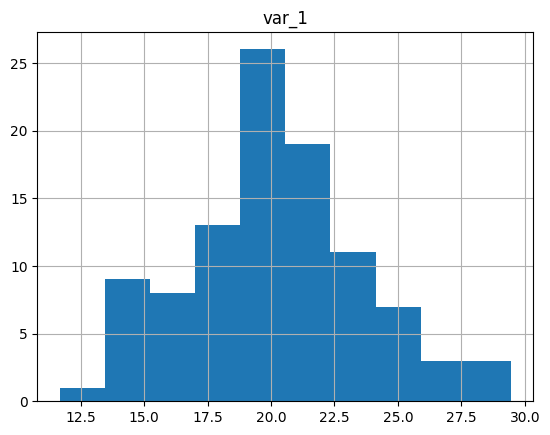

In [68]:
my_df.hist()
plt.show()

In [69]:
my_df['var_2'] = my_df['var_1'].apply(lambda x: (x*3+5))
my_df #Transformación lineal cuando se aplica una suma y una multiplicación de una variable

,var_1,var_2
0,23.295266,74.885799
1,17.855663,58.566990
2,29.450127,93.350381
3,14.473712,48.421137
4,20.714678,67.144035
...,...,...
95,23.840080,76.520240
96,21.873263,70.619789
97,18.627535,60.882606
98,20.294567,65.883700


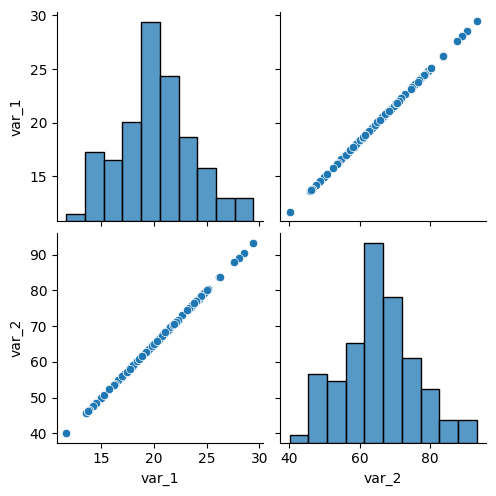

In [70]:
sns.pairplot(data=my_df)
plt.show() # una transformaición lineal no cambia en la proporción, solo cambia la posición y escala

In [71]:
my_df.corr() #La correlación es perfecta por que hay una correlación lineal

,var_1,var_2
var_1,1.0,1.0
var_2,1.0,1.0


In [72]:
noise = np.random.normal(loc=0, scale=1, size=100)
my_df['var_3'] = my_df['var_2'] + noise
my_df

,var_1,var_2,var_3
0,23.295266,74.885799,73.113849
1,17.855663,58.566990,58.304813
2,29.450127,93.350381,92.776082
3,14.473712,48.421137,48.900857
4,20.714678,67.144035,67.549096
...,...,...,...
95,23.840080,76.520240,76.279642
96,21.873263,70.619789,68.409967
97,18.627535,60.882606,60.130333
98,20.294567,65.883700,65.726179


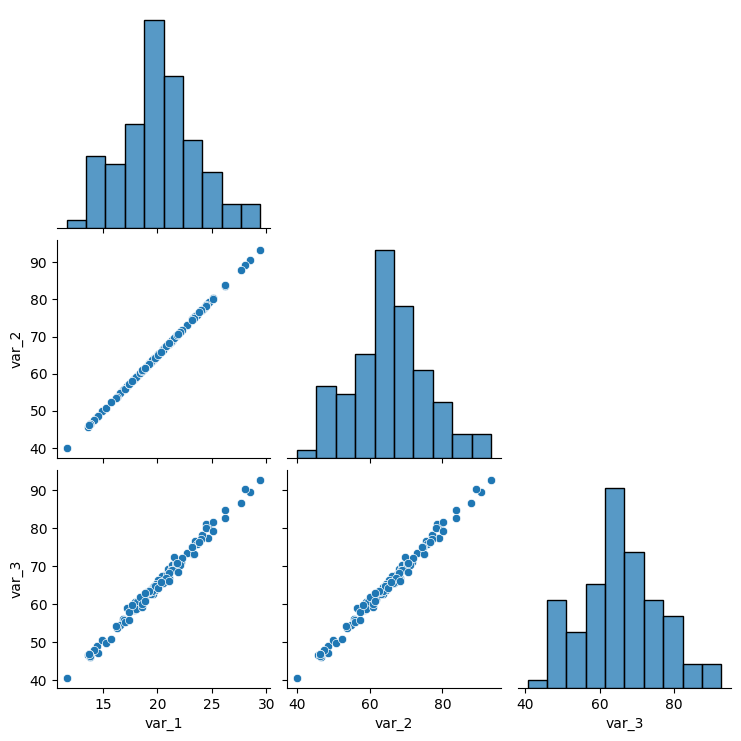

In [73]:
sns.pairplot(data=my_df, corner=True )
plt.show()
#Se observan una linea pero no es perfecta

In [74]:
my_df.corr()
#Cuando la correlación es positiva es porque la relación lineal uno crece y el otro crece y la correlación negativa
#es por que uno crece y el otro decrece
#La idea es buscar la correlación en el EDA

,var_1,var_2,var_3
var_1,1.000000,1.000000,0.995373
var_2,1.000000,1.000000,0.995373
var_3,0.995373,0.995373,1.000000


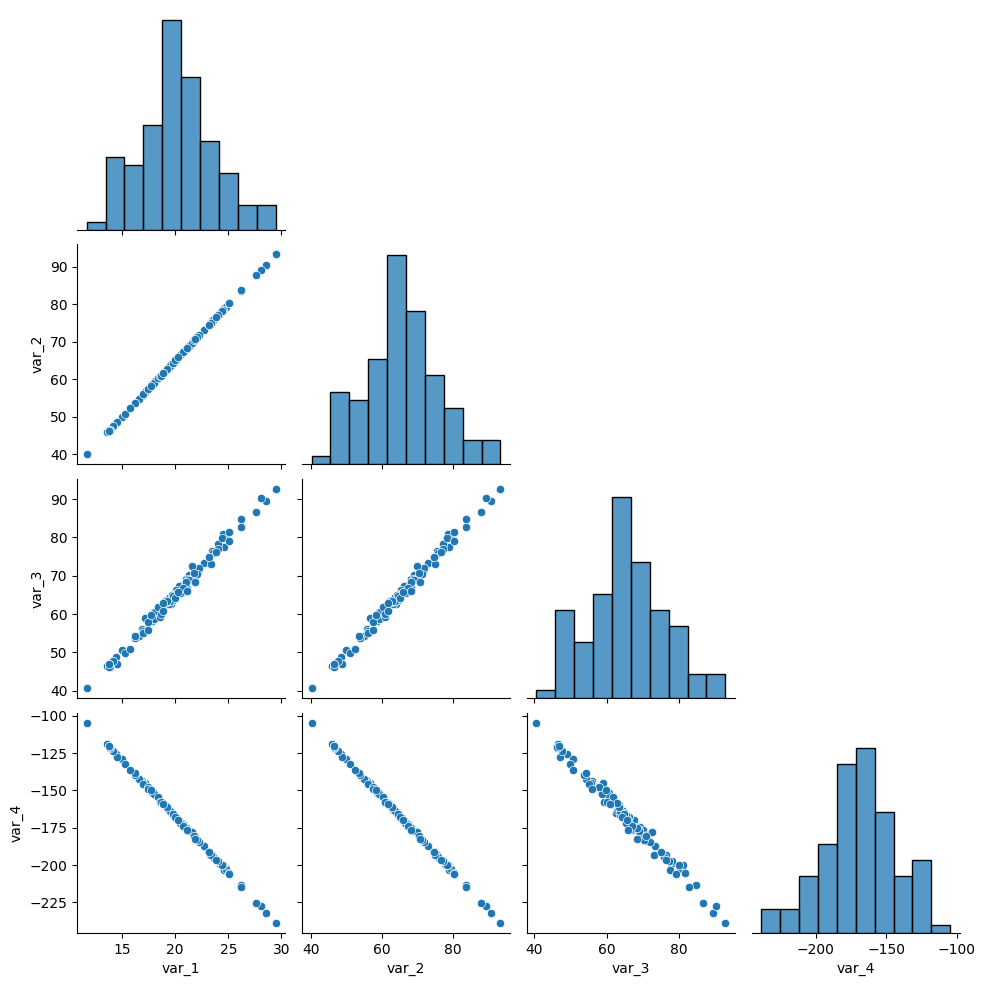

In [75]:
my_df['var_4'] = (3*my_df['var_1']) - (4*my_df['var_2']) + (0.5*my_df['var_3'])
sns.pairplot(data=my_df, corner=True)
plt.show()
#La variable 4 ha sufrido una transformación
#La regresion lineal asume para una variable continua, y el Y tiene que ser continua
#X es la matriz de vectores(predictore)
#Y es el objetivo Y=BX + alfa + N : Beta= coeficiente, alfa= intercepto, N = ruido
# copntinuo= un conjunto de vectores beta por una variable más un alfa y= B1X1 + B2X2+...BnXn+ B0

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [77]:
url_train = "https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_salary_train.csv"
url_test ="https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_salary_test.csv"


In [78]:
df_train = pd.read_csv(url_train)
df_test = pd.read_csv(url_test)
df_train.info()
#La variable dependiente o objetivo es el salario
#El salario es una consecuencia de los años de experiencia

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  24 non-null     float64
 1   Salary           24 non-null     float64
dtypes: float64(2)
memory usage: 516.0 bytes


In [79]:
#Step 2: preprocessing
df_train.columns = df_train.columns.str.lower()
df_test.columns = df_test.columns.str.lower()

In [80]:
df_train.describe().T
#Esta ligeramente desviasdo

,count,mean,std,min,25%,50%,75%,max
yearsexperience,24.0,5.2125,2.776816,1.1,3.2,4.5,7.30,10.5
salary,24.0,74714.8750,26365.625646,39343.0,56430.0,65237.0,99030.25,121872.0


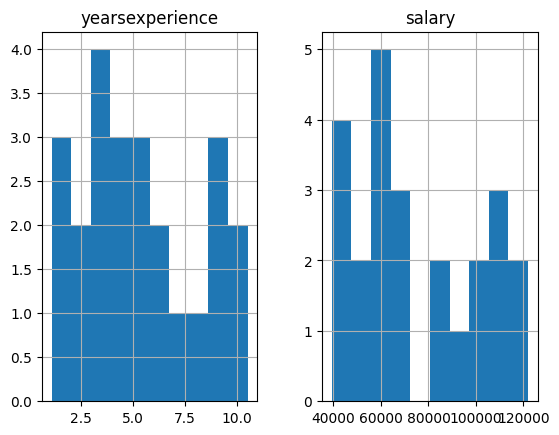

In [81]:
df_train.hist()
plt.show()
#Estas variables no son tan simetricas

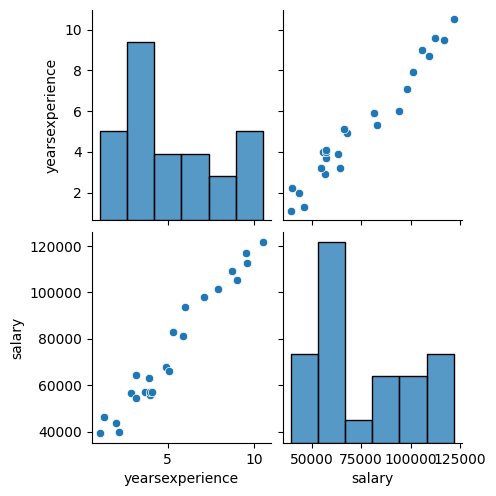

In [82]:
sns.pairplot(data=df_train)
plt.show()
#Visualmente si es una regresión lineal, pero se comprueba con la correlación

In [83]:
df_train.corr() #la correlación de 0.97 es bastante lineal

,yearsexperience,salary
yearsexperience,1.000000,0.977132
salary,0.977132,1.000000


In [84]:
#Setep 4: Machine Learning
#Separar las variables predectivas (X) de las objetivas (Y)
X_train = df_train[['yearsexperience']] #Doble brackets recto por que tiene que ser un dataframe
y_train = df_train['salary'] #Tiene que ser un vector

X_test = df_test[['yearsexperience']]
y_test = df_test['salary']

linear_model = LinearRegression()
linear_model.fit(X_train, y_train) #Aprendizaje es el train

LinearRegression()

In [85]:
y_hat = linear_model.predict(X_test) #Predecir
print(f'MSE(Mean squared error) : {mean_squared_error(y_test, y_hat)}')
print(f'MAE(Mean absolute error) : {mean_absolute_error(y_test, y_hat)}')
print(f'RMSE(Root mean squared error) : {np.sqrt(mean_squared_error(y_test, y_hat))}')

#Bajo la prediccioin seria el valor de la predcción (y_hat)
# y_hat +- RMSE o y_hat +- MAE
#Quiere decir en general me equivoco 6mil dol con respecto al salario verdadero
#¿Que utilizo RMSE o MAE? MAE sin penalización, cuando utilizo RMSE los errores se penalizan más porque
#un error al cuadro es tremendamente grande

MSE(Mean squared error) : 37649779.451336615
MAE(Mean absolute error) : 4940.929321407512
RMSE(Root mean squared error) : 6135.941610815459


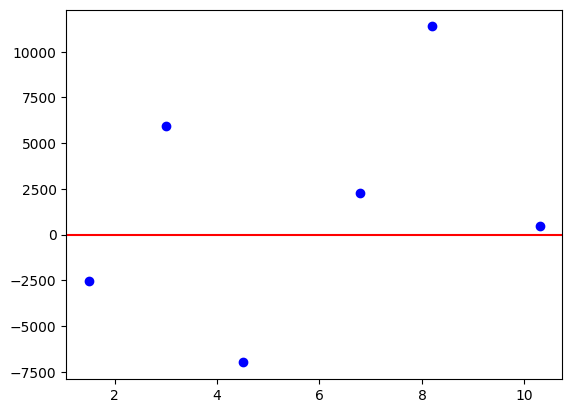

In [86]:
#Residual, diferencia entre la predicción y el valor real
residual = y_test - y_hat
plt.scatter(X_test, residual, color='b')
plt.axhline(y=0, color='r')
plt.show()
#No se muestra ninguna linea en los residuales, no hay correlación, por lo tanto si puedo aplicar regresion lineal


In [87]:
#Encontrando los coeficientes
linear_model.intercept_

np.float64(26354.43069701219)

In [88]:
linear_model.coef_

array([9277.78307971])

In [89]:
#y_hat = 26354.4 + 9277.8*yearsexperience
def prediction(coef, intercept, x):
  return intercept + coef*x

prds = prediction(9277.8, 26354.4, X_train)
prds


,yearsexperience
0,36559.98
1,38415.54
2,44910.00
3,46765.56
4,53260.02
5,56043.36
6,56043.36
7,60682.26
8,62537.82
9,63465.60


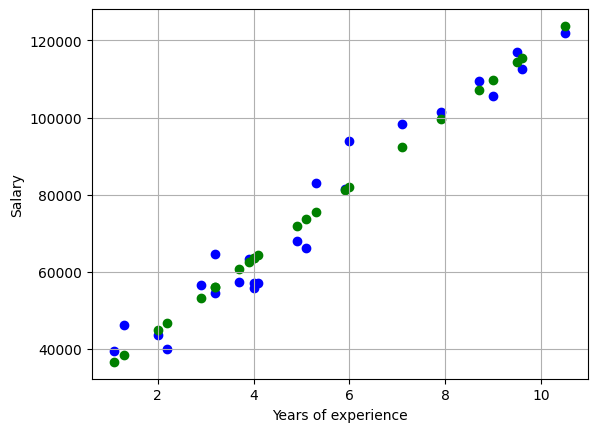

In [90]:
plt.scatter(x=X_train, y=y_train, color='b') #Valores reales
plt.scatter(x=X_train, y=prds, color='g') #prediccion
plt.grid(True)
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.show()
#Para poder usar la regresion lineal, necesitamos estas condiciones
#Los valores azules son los valores reales y los verdes es la linea de regresion que se ha generado
#El ruido es el error, la distancia del punto azul al verde
#Regresion lineal con una sola variable
#Existe una relacion lineal entre los predictores y el objetivo? si
#Existe independiencia entre los predictores? si
#La varianza es constante?, si y se ve en la grafica de los residuales
#Los errores son normalente distribuidos? Si

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder #Transforma las variables categórica a numéricas
from sklearn.linear_model import Lasso, Ridge

In [92]:
#Step 1: Load data
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv'
df_raw = pd.read_csv(url)
df_raw.info()
#Varaible dependiente o objetivo es cargo
#Variable independiente o predictora es age, sex, bmi, childreml smoker, region

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [93]:
df_raw.sample(10, random_state=2025)
#X = [age,sex,bmi,children,smoker,"region"] Para aplicar ML todas las variables tienen que ser números y
#region es texto ahi se va hacer una transformación
#y = [charges]

,age,sex,bmi,children,smoker,region,charges
1269,45,male,27.500,3,no,southwest,8615.30000
942,18,female,40.185,0,no,northeast,2217.46915
1240,52,male,41.800,2,yes,southeast,47269.85400
1229,58,male,30.305,0,no,northeast,11938.25595
272,41,male,37.050,2,no,northwest,7265.70250
738,23,male,31.730,3,yes,northeast,36189.10170
1105,54,female,31.240,0,no,southeast,10338.93160
1182,25,female,30.300,0,no,southwest,2632.99200
14,27,male,42.130,0,yes,southeast,39611.75770
596,42,female,29.480,2,no,southeast,7640.30920


In [94]:
#Step 2: Preproccesing
df_baking = df_raw.copy()
df_baking['sex'] =df_baking['sex'].astype('category')
df_baking['region'] =df_baking['region'].astype('category')
df_baking['smoker'] =df_baking['smoker'].astype('category')
df_baking['dummy'] =np.random.normal(loc=10, scale=1, size=1338) #Ejemplo de variable que no tiene nada que ver von el dataset
df_baking['charges'] = np.log(df_baking['charges'])
df = df_baking.copy()
df.info() #Aun sigue siendo texto

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int64   
 1   sex       1338 non-null   category
 2   bmi       1338 non-null   float64 
 3   children  1338 non-null   int64   
 4   smoker    1338 non-null   category
 5   region    1338 non-null   category
 6   charges   1338 non-null   float64 
 7   dummy     1338 non-null   float64 
dtypes: category(3), float64(3), int64(2)
memory usage: 56.8 KB


$D: 1338*7$ Data set inicial  
$D_ {train}: 1204*7$ Data set de aprendizaje  
$D_ {test}: 134*7$ Data set de pruebas  
$X_ {train}: 1204*6$ Matriz de aprendizaje(predictores)  
$Y_ {train}: 134*1$ Vector de resultante(objetivos)  
$X_ {test}: 1204*1$ Matriz de prueba(predictor)  
$Y_ {test}: 134*1$ Vector de prueba(objetivo)  

Predictors_numeric: Age, bmi, children  
Predictor_binary: sex, smoker  
Predictor_category: region  
Total_predictor_pipeline: 8 (3 numeric + 2 binary + (4-1) Cateogory)  


In [95]:

#Step 3: EDA
df_train, df_test = train_test_split(df, test_size=0.1, random_state=2025)
df_train = df_train.reset_index(drop=True) #Si no le pongo el drop el indice que se resetea se añade como columna
df_test = df_test.reset_index(drop=True)
df_train.shape, df_test.shape

((1204, 8), (134, 8))

In [96]:
display(df_train.describe(include='number').T)
display(df_train.describe(include='category').T)
#Se peude hacer una transformación en la variable charges siempre cuando no haya cero por que no hay logaritmo de cero
#La idea es ver que baje la dispersión

,count,mean,std,min,25%,50%,75%,max
age,1204.0,39.181063,14.151788,18.000000,26.000000,39.000000,51.000000,64.000000
bmi,1204.0,30.643800,6.086388,15.960000,26.220000,30.400000,34.717500,53.130000
children,1204.0,1.093854,1.199333,0.000000,0.000000,1.000000,2.000000,5.000000
charges,1204.0,9.103639,0.920947,7.022756,8.464704,9.151006,9.736511,11.063045
dummy,1204.0,10.037617,1.013834,6.188054,9.362425,10.000606,10.738472,12.990421


,count,unique,top,freq
sex,1204,2,male,604
smoker,1204,2,no,956
region,1204,4,southeast,320


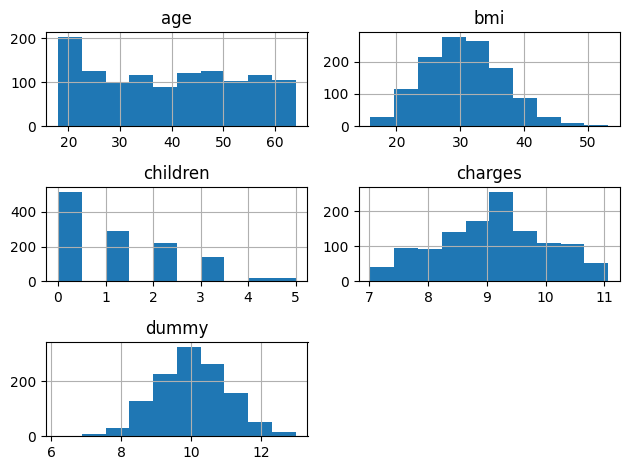

In [97]:
#Analisis univariado
df_train.hist()
plt.tight_layout()
plt.show()
#BMI tiene una distribución razonablemente simétrica. Children y charges tiene sesgo
#df_baking['charges'] = np.log(df_baking['charges']) --> Al hacer esa transformación charges ya cambio

<Axes: xlabel='sex', ylabel='count'>

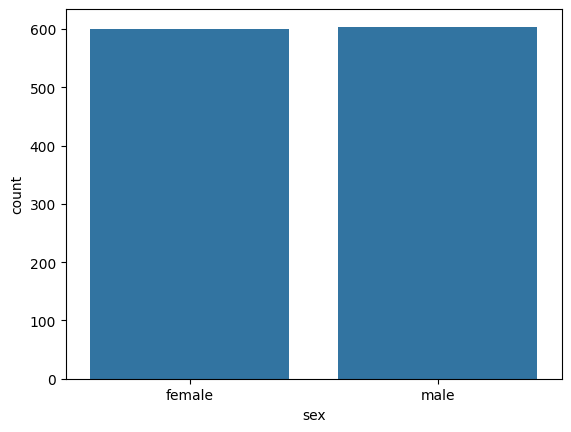

In [98]:
#Pintamos las variables categoricas
sns.countplot(df_train, x='sex')

<Axes: xlabel='smoker', ylabel='count'>

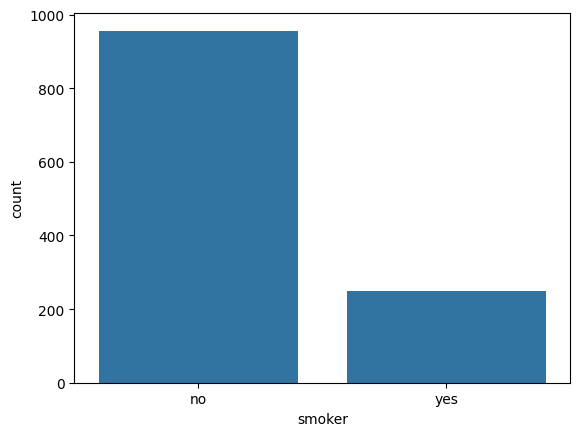

In [99]:
sns.countplot(df_train, x='smoker')

<Axes: xlabel='region', ylabel='count'>

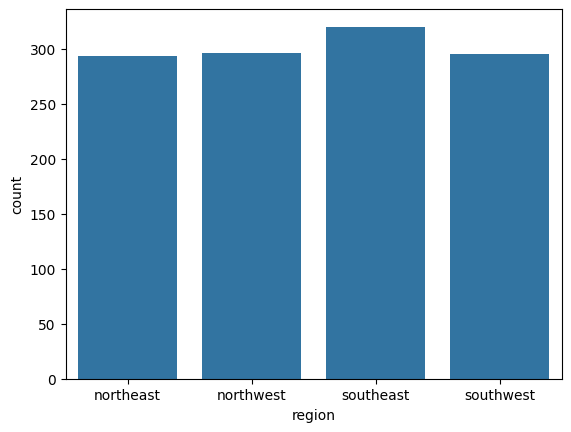

In [100]:
sns.countplot(df_train, x='region')

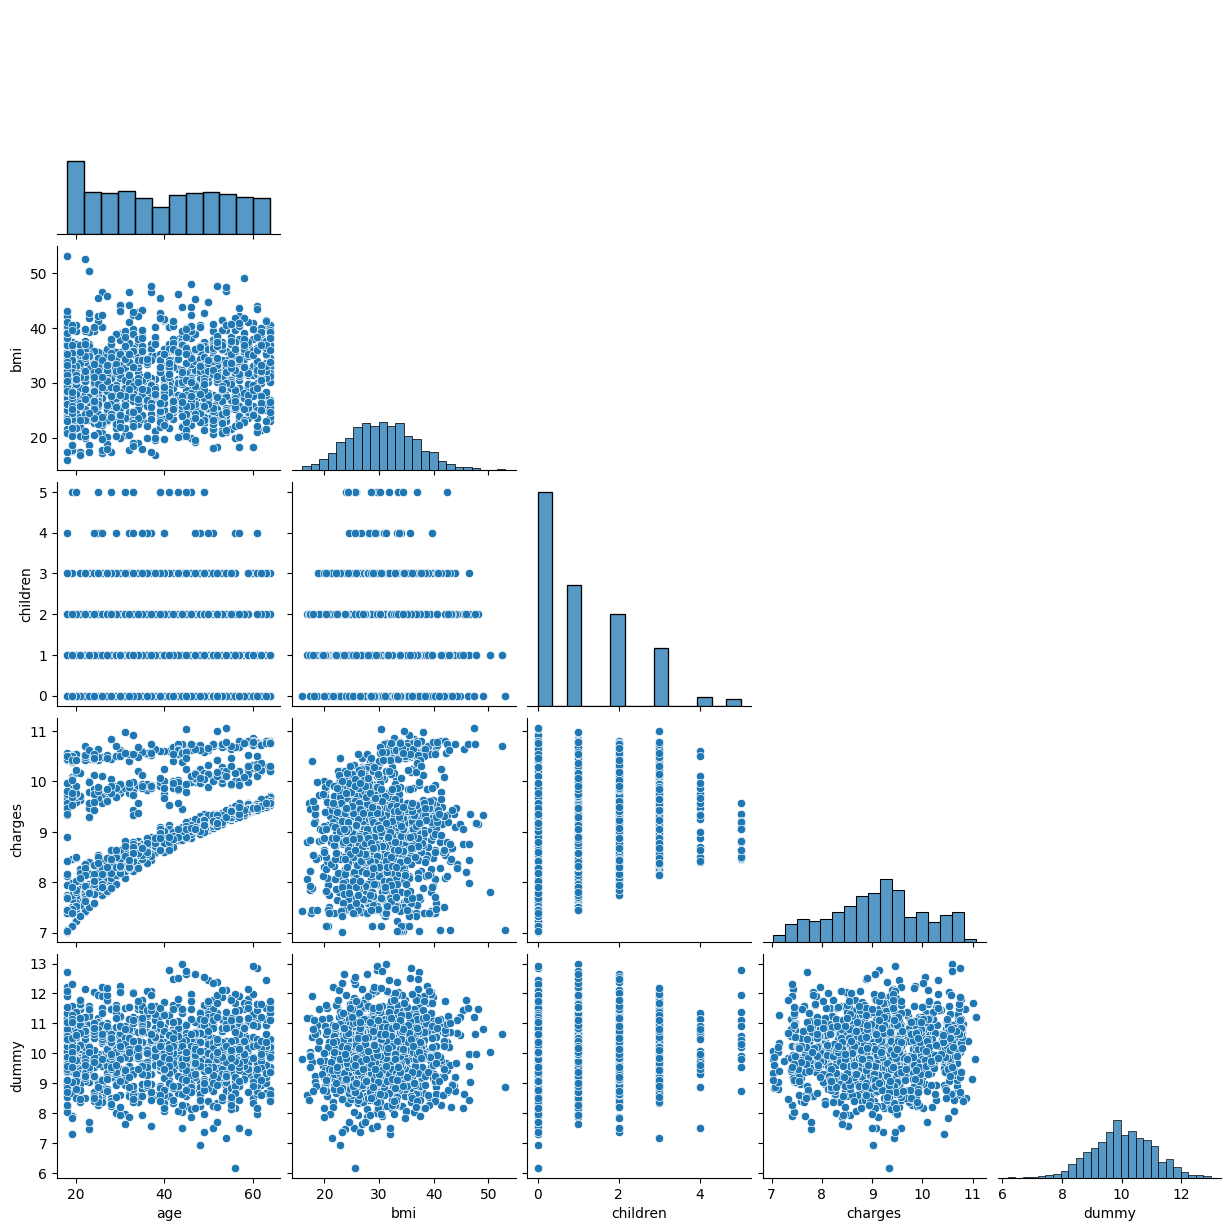

In [101]:
#Análisis bivariado para datos númericos
sns.pairplot(data = df_train, corner= True)
plt.show()
#Nuestra variable de interes es el charge
#Las variables independientes no forman una linea
#La gráfica de age y charges se observa 3 lineas paralelas y en las demás gráficas no se observa nada

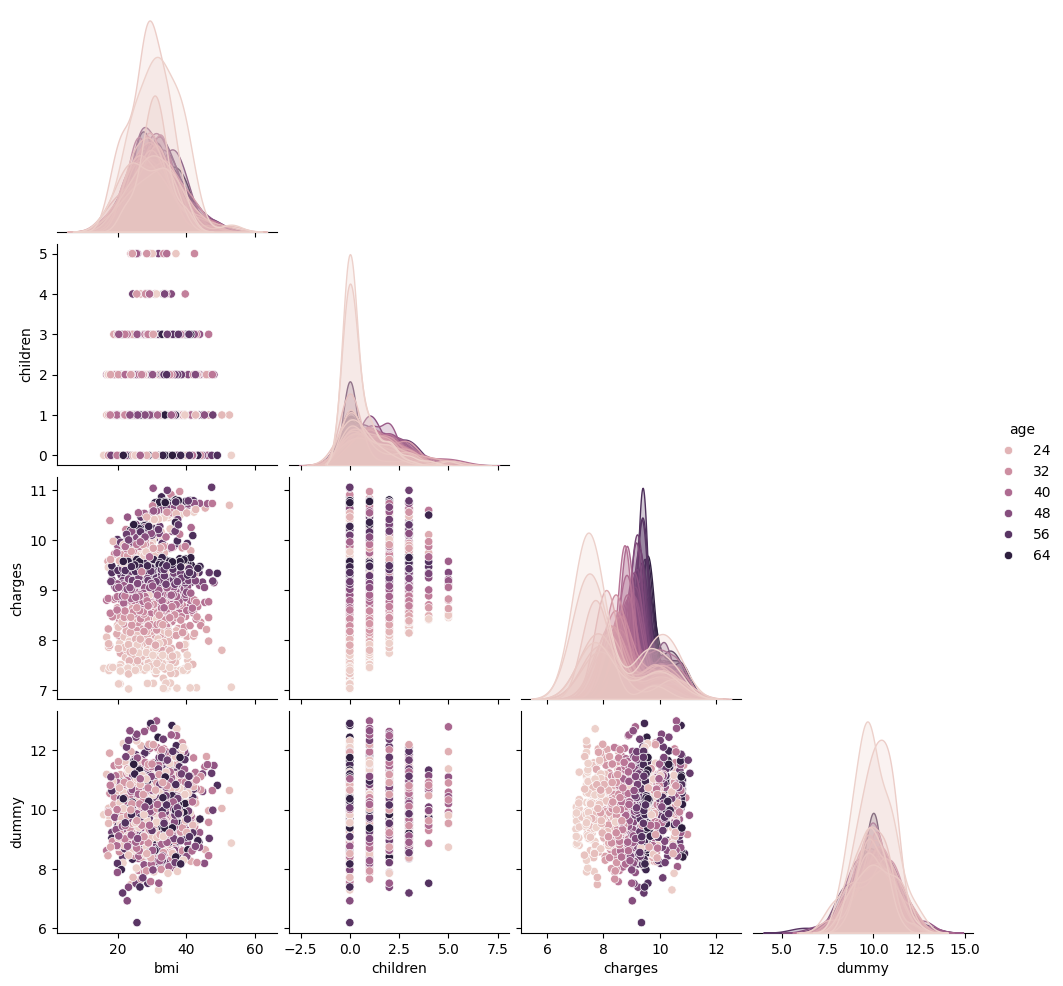

In [102]:
#comparamos numericos contra categoricos
sns.pairplot(df_train, hue='age', corner=True)
plt.show()

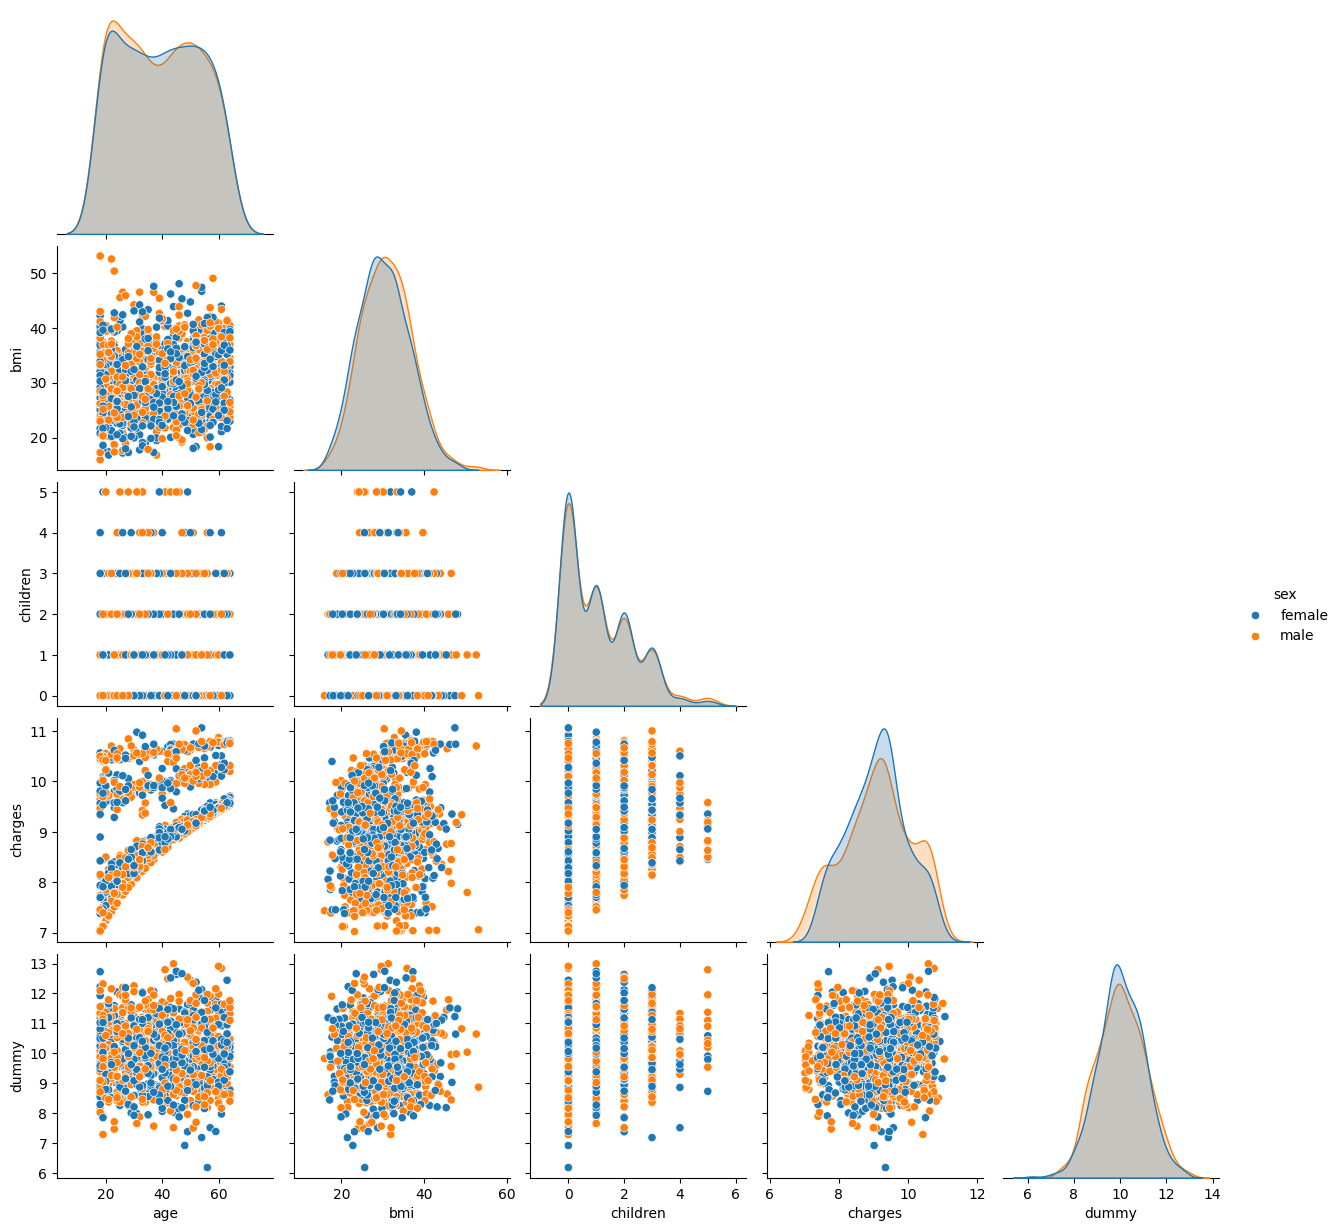

In [103]:
#comparamos numericos contra categoricos
sns.pairplot(df_train, hue='sex', corner=True)
plt.show()

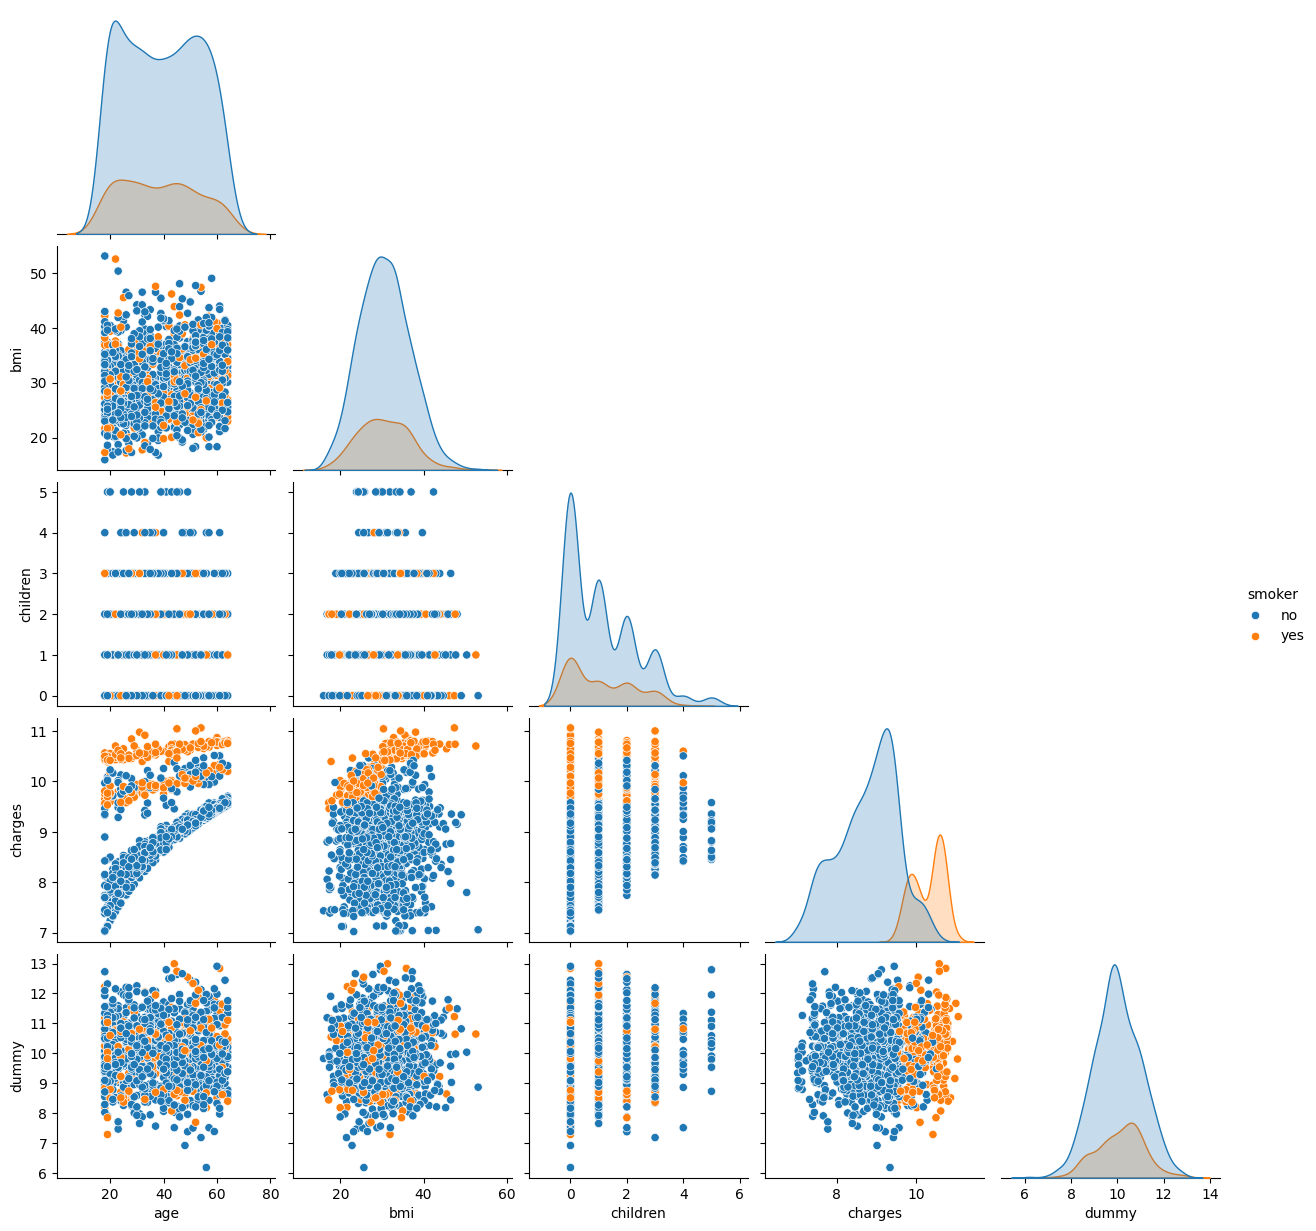

In [104]:
sns.pairplot(df_train, hue='smoker', corner=True)
plt.show()
#Si fumas tus cargos son más altos

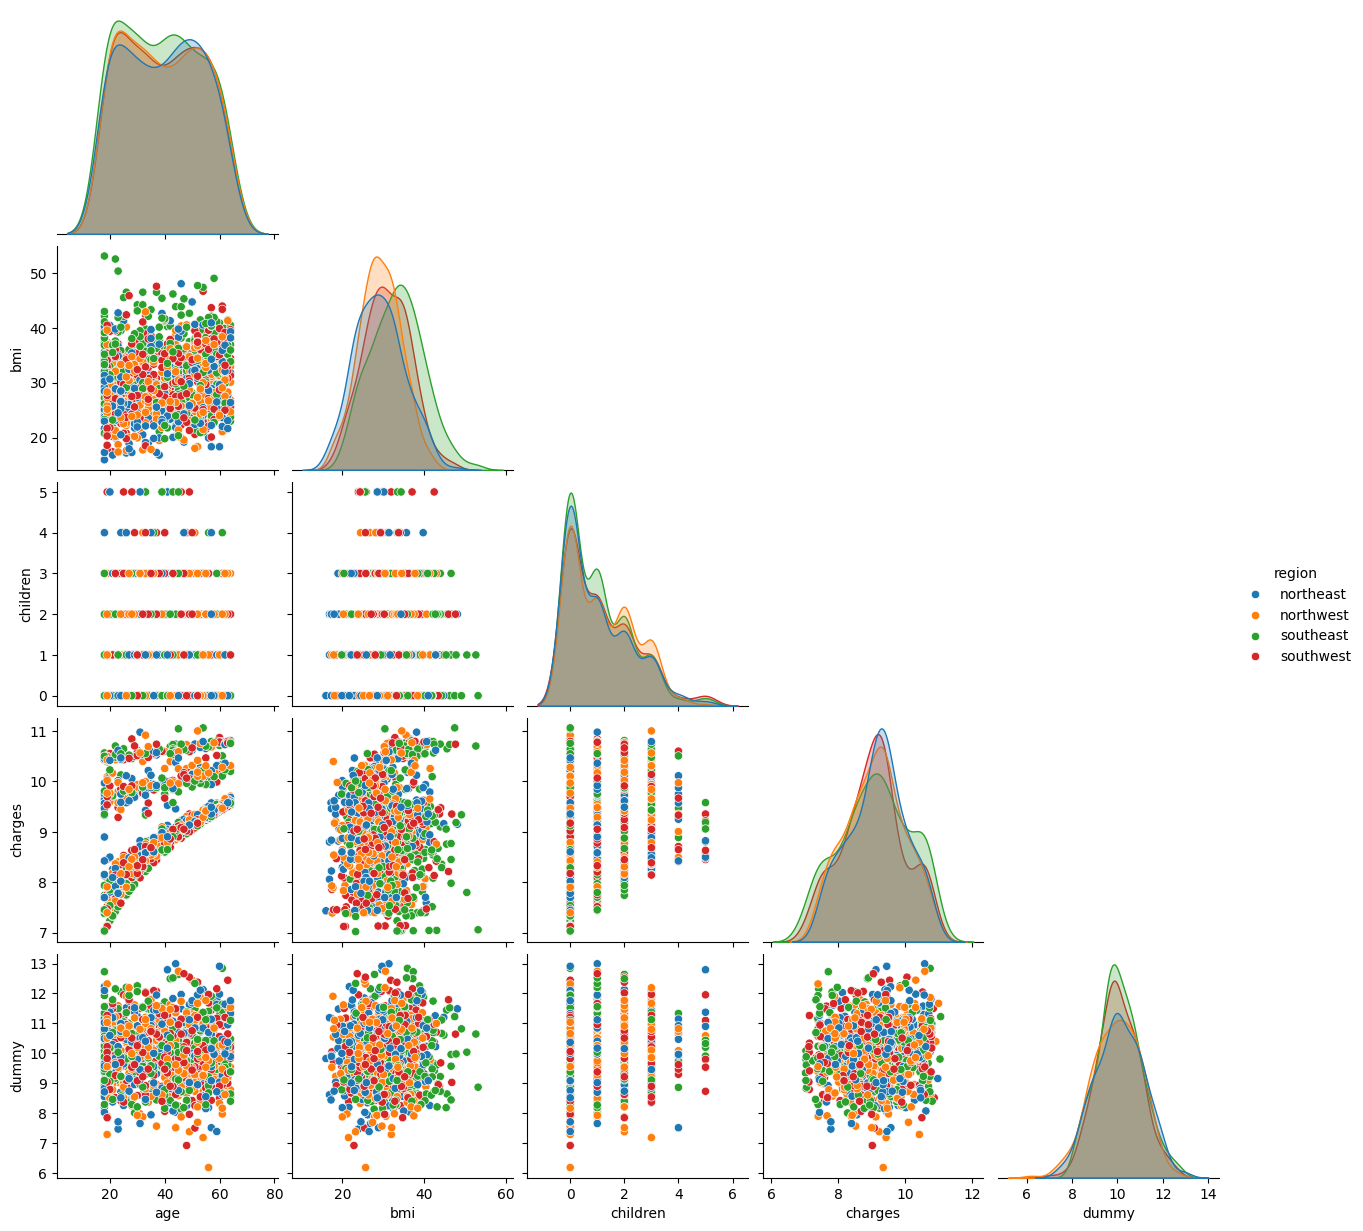

In [105]:
#comparamos numericos contra categoricos
sns.pairplot(df_train, hue='region', corner=True)
plt.show()

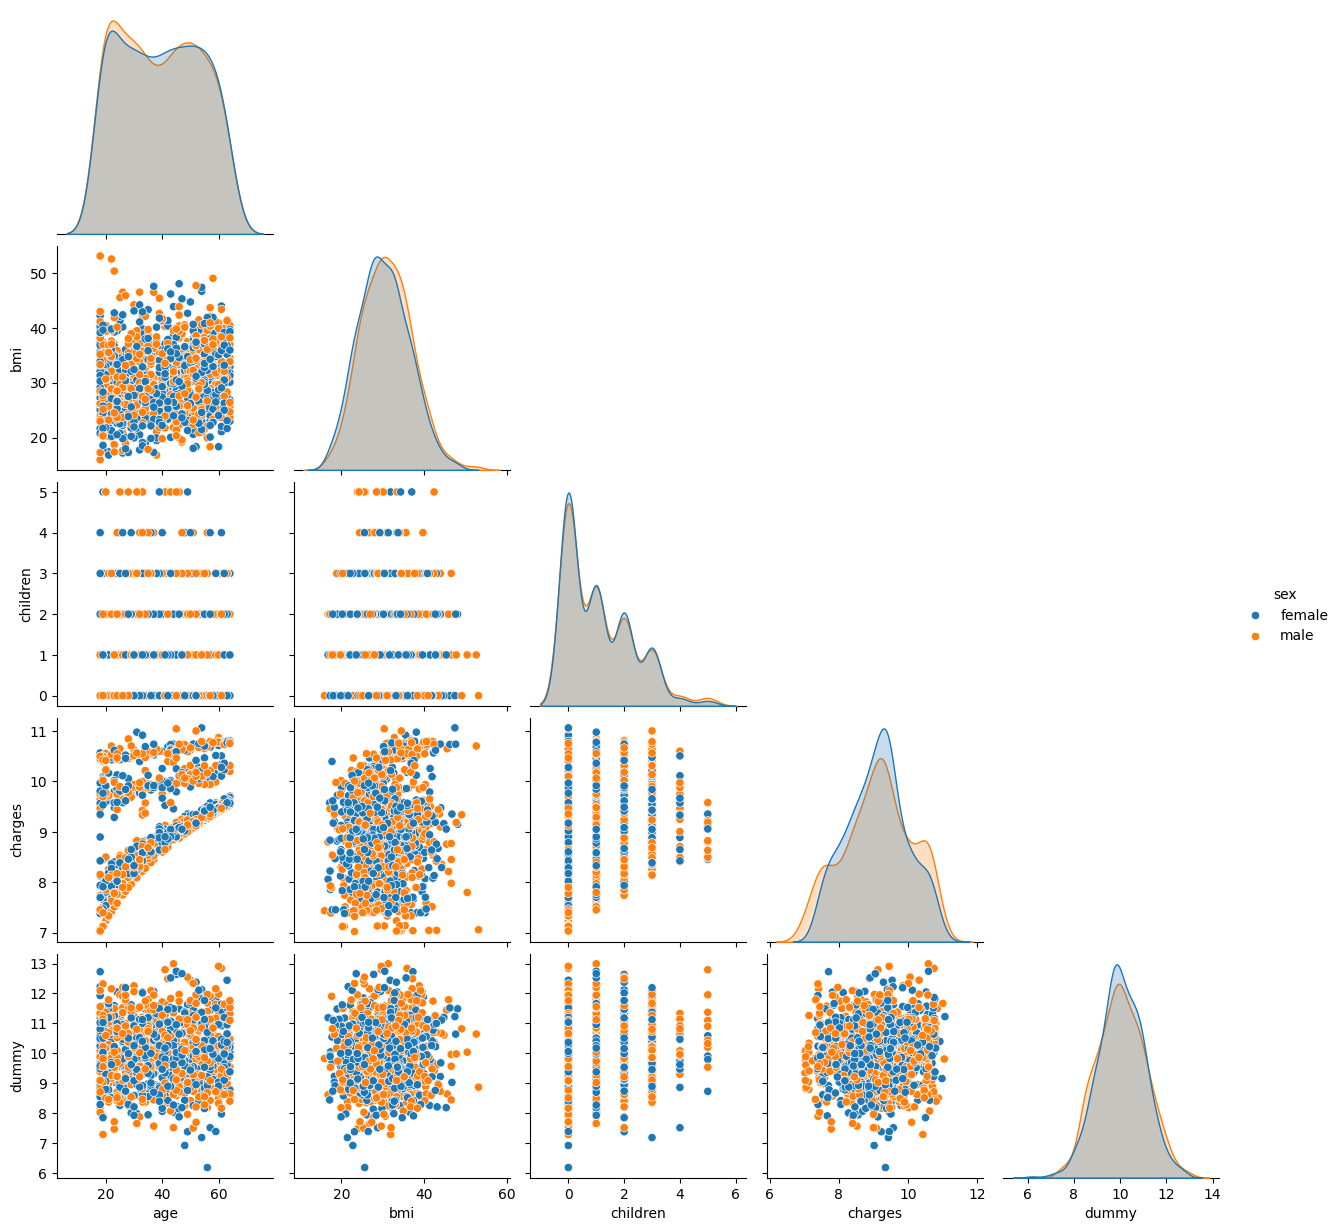

In [106]:
#comparamos numericos contra categoricos
sns.pairplot(df_train, hue='sex', corner=True)
plt.show()

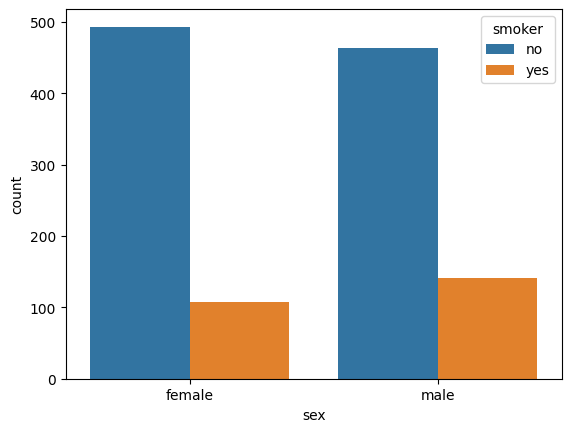

In [107]:
#Comparamos categorico contra cateogtrico
sns.countplot(df_train, x='sex', hue='smoker')
plt.show()
#Las mujeres fuman mas, pero es casi similar
#Se ve que baja uno y sube el otro

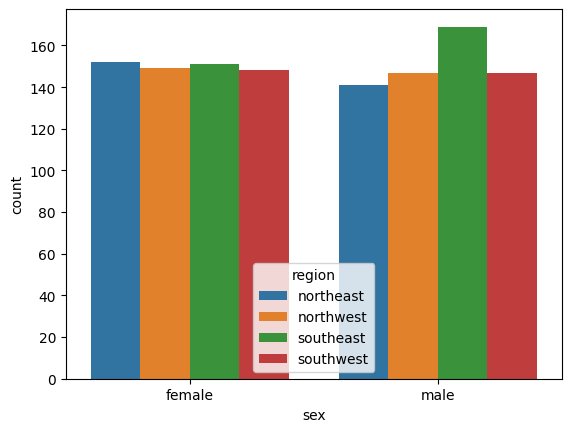

In [108]:
sns.countplot(df_train, x='sex', hue='region')
plt.show()
#Hay más hombres en southeast

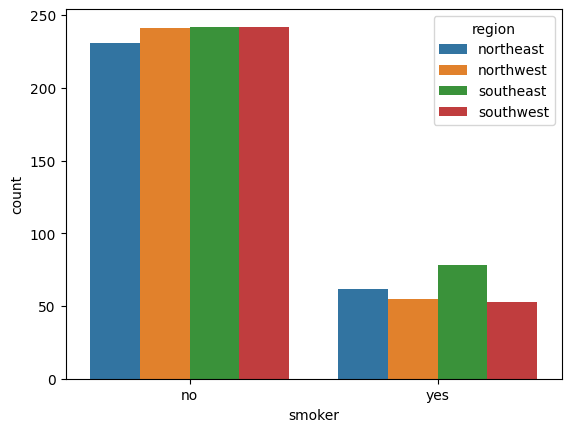

In [109]:
sns.countplot(df_train, x='smoker', hue='region')
plt.show()
#En el southheast hay más fumadores

In [110]:
#Step 4: Machine learning
#Vamos a borrar la variable dependiente o la que no queremos
X_train= df_train.drop(columns='charges')
y_train = df_train['charges']

X_test= df_test.drop(columns='charges')
y_test = df_test['charges']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1204, 7), (1204,), (134, 7), (134,))

In [111]:
#Necesitamos convertir las variables de texto a números, vamos hacer un pipline una tuberia
num_cols = X_train.select_dtypes('number').columns #Lista de todas las variables numéricas
cat_cols = X_train.select_dtypes('category').columns #Rango 0 y 1 #Lista de todas las variables cateogricas

#Escribimos la tuberia
num_proc = Pipeline(steps=[ #Procesador de los números
    ('scaler',MinMaxScaler()) #MinMaxScaler escalan los valores de una variable entre cero y uno
])
#Para valores razonablemente simetrico se puede aplicar el StandarScaler escalando los valores a un promedio cero y desviación estandar a uno
cat_proc = Pipeline(steps=[
    ('onehot',OneHotEncoder(drop='first')) #Para transformar las variables categoricas en números
]) #Aca dentro del parentisis indicamos que quede en 2 o 3 variables o hacemos un drop de la variable de referencia
processor = ColumnTransformer(transformers=[
    ('num',num_proc, num_cols),
    ('cat',cat_proc, cat_cols)
])
reg_lr = Pipeline(steps=[
    ('proce', processor),
    ('lreg',LinearRegression())
])

#Cuando pasen datos en esta tuberia se van a separar los datos categoricos de numericos, luego van a ser procsados o modificados
#y van a pasar por la tuberia principal donde se hacer reprocesamiento y se aplica la regresion lineal

In [126]:
reg_lr.fit(X_train, y_train)
y_hat = reg_lr.predict(X_test)

print(f'MSE(Mean squared error) : {mean_squared_error(y_test, y_hat)}') #prueba, prediccion
print(f'MAE(Mean absolute error) : {mean_absolute_error(y_test, y_hat)}')
print(f'RMSE(Root mean squared error) : {np.sqrt(mean_squared_error(y_test, y_hat))}')
print(f'R2(R SQUEARE) : {r2_score(y_test, y_hat)}')# Porcentaje de la variabilidad, cuanto más cerca al 1 es mejor caso contrario peor

#Me voy a equivocar 5,393 dolares al predecir si queremos ser mas conservadores uso el MSE
# R2 -> Con la transformación explica el 81% de la variabilidad (0.8167177699660128). Sin la transformación sale 0.78

MSE(Mean squared error) : 0.15026163769074405
MAE(Mean absolute error) : 0.24460948753528072
RMSE(Root mean squared error) : 0.38763596026522623
R2(R SQUEARE) : 0.8167177699660128


In [113]:
#Calculamos los coeficientes
reg_lr['lreg'].intercept_

np.float64(7.904297618429452)

In [114]:
#los betas: Beta0...Beta8
reg_lr['lreg'].coef_  #Solo en la regresion lineal y con los Beta1..Betan, cuanto más grande el coeficiente mas importante es la variab
#La variable que pesa es smoker, bmi, edad
#Y con respecto a la variable de referencia se reduce la prima si soy de la región SE por que esta mas pegado al negativo (-993.6)
#y la otra variable que reduce es si soy hombre
#salio 11 por que falta  ('onehot',OneHotEncoder(drop='first')), luego quedo 8 coeficientes
#El modelo de regresion lineal asume independecia entre los predictores

array([ 1.57880085,  0.48953081,  0.52027686, -0.06100359, -0.07992264,
        1.55546764, -0.04968068, -0.15418526, -0.11192228])

In [115]:
reg_lr['proce'].get_feature_names_out()
#Orden de los coeficientes del paso anterior

array(['num__age', 'num__bmi', 'num__children', 'num__dummy',
       'cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest',
       'cat__region_southeast', 'cat__region_southwest'], dtype=object)

$$y=β_0+β_1*age+β_2*bmi+β_3*children+β_4*malesex+β_5*smokeryes+β_6*regionnw+β_7*regionse+β_8*regionsw$$

$$y=-2141.8+12017.6*age+12671.9*bmi+2771.3*children-198.4*malesex+23859.7*smokeryes-148.4*reginnw-993.7*regionse-705.4*regionsw$$

In [116]:
#Step 5: Predictor model
df_train.head(2) #Este df es una lista

,age,sex,bmi,children,smoker,region,charges,dummy
0,22,male,35.60,0,yes,southwest,10.479696,11.053609
1,19,male,35.53,0,no,northwest,7.406364,9.847964


In [117]:
my_value = pd.DataFrame({
    'age':[22],
    'sex':['male'],
    'bmi':[35.60],
    'children':[0],
    'smoker':['yes'],
    'region':['southwest'],
    'dummy':[10]
})
reg_lr.predict(my_value)
#La predicción de cargos de seguros es 28554.5
#Este modelo es una aproximación, el error no se puede reducir pero si se puede optimizar los betas

array([9.62968166])

In [118]:
my_value = pd.DataFrame({
    'age':[19],
    'sex':['male'],
    'bmi':[35.53],
    'children':[0],
    'smoker':['no'],
    'region':['northwest'],
    'dummy':[10]
})
reg_lr.predict(my_value)
#La predicción de cargos de seguros es 28554.5
#Este modelo es una aproximación, el error no se puede reducir pero si se puede optimizar los betas
#Para el age 19 el charges salio 1646, pero en la prediccion sale 4444 se equivoco por 3mil y algo que no es malo
#LR es econoimico, interpretable

array([8.03256845])

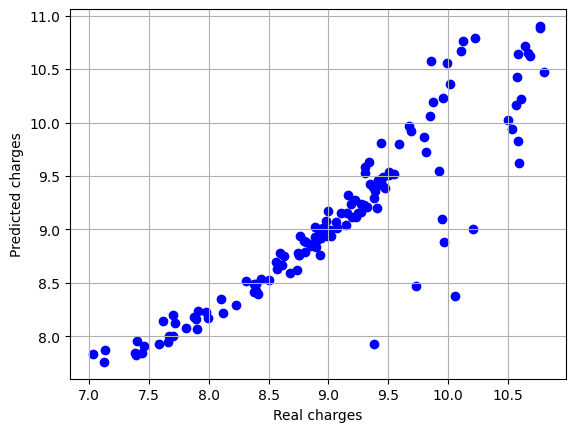

In [119]:
#Bondad del ajuste entre y_test(el verdadero) y y_hat (predictor)
plt.scatter(x=y_test, y=y_hat, color='b')
plt.grid(True)
plt.xlabel('Real charges')
plt.ylabel('Predicted charges')
plt.show()
#Si hubiera sido un buen ajuste hubiera sido equidistante y esto se debe a que tal vez hay dependencia en las variables
#Si un persona es fumadora hay chance de que tenga un alto bmi? si


In [120]:
reg_lasso = Pipeline(steps=[
    ('proce', processor),
    ('reg_lasso',Lasso(alpha=100)) #Conforme vamos tuneando vemos que variable se va
    #Las varuiables que quedaron y es suficiente para tener un modelo aceptable es:
    #'num__age', 'num__bmi', 'num__children','cat__smoker_yes',
])
reg_lasso.fit(X_train, y_train)
y_hat = reg_lasso.predict(X_test)

print(f'MSE(Mean squared error) : {mean_squared_error(y_test, y_hat)}')
print(f'MAE(Mean absolute error) : {mean_absolute_error(y_test, y_hat)}')
print(f'RMSE(Root mean squared error) : {np.sqrt(mean_squared_error(y_test, y_hat))}')

MSE(Mean squared error) : 0.8223103062398401
MAE(Mean absolute error) : 0.7171625517497415
RMSE(Root mean squared error) : 0.906813269774897


In [121]:
reg_lasso['reg_lasso'].coef_

array([ 0.,  0.,  0.,  0.,  0.,  0., -0., -0., -0.])

In [122]:
reg_lasso['proce'].get_feature_names_out()

array(['num__age', 'num__bmi', 'num__children', 'num__dummy',
       'cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest',
       'cat__region_southeast', 'cat__region_southwest'], dtype=object)

In [123]:
reg_ridge = Pipeline(steps=[
    ('proce',processor),
    ('reg_ridge',Ridge(alpha=100))
])
reg_ridge.fit(X_train, y_train)
y_hat = reg_ridge.predict(X_test)

print(f'MSE(Mean squared error) : {mean_squared_error(y_test, y_hat)}')
print(f'MAE(Mean absolute error) : {mean_absolute_error(y_test, y_hat)}')
print(f'RMSE(Root mean squared error) : {np.sqrt(mean_squared_error(y_test, y_hat))}')
#Lasso para ver si puedo descartar una variable innecesaria
#Ridge para ver si puedo tunear una variable

MSE(Mean squared error) : 0.27742228846269085
MAE(Mean absolute error) : 0.37777709730593034
RMSE(Root mean squared error) : 0.526708921950911


In [124]:
reg_ridge['reg_ridge'].coef_

array([ 0.84814211,  0.12965258,  0.22300117,  0.00872466, -0.03562213,
        1.01568123, -0.01045342, -0.05109819, -0.04853641])

In [125]:
reg_lasso['proce'].get_feature_names_out()

array(['num__age', 'num__bmi', 'num__children', 'num__dummy',
       'cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest',
       'cat__region_southeast', 'cat__region_southwest'], dtype=object)